# RPG development part 1: world, player and NPCs
* an **RPG** (role playing game) is one of the oldest and most beloved video game genres - think early Zelda, Pokemon or Final Fantasy style games: you walk around a world made of tiles, you talk to NPCs (non-player characters), you collect items, and you fight monsters in battles
* this whole game-dev arc of the course has been building towards exactly this: lesson 27 gave us the pygame fundamentals (drawing, the game loop, input, collision), and lessons 29/30 (being written alongside this one) cover sprites/animation/tilemaps and procedural map generation in more depth
* an RPG basically combines ALL of that: a tile-based world you walk around on (a 2D grid), characters (the player + NPCs) that live on that grid, collision with walls/obstacles so you cant just walk through everything, and (this is the important part for THIS lesson) a dialogue system so NPCs can actually talk to you
* this is a **two-part capstone**: THIS lesson (part 1) builds the "walking around a world, talking to people" half of an RPG. lesson 32 (part 2) builds the "items and turn-based combat" half and ties everything together into one small but genuinely playable mini RPG
* like every lesson in this game-dev arc, this notebook is self-contained - we recap the tile-map/sprite ideas from scratch in our own words, we dont import anything from the other lesson notebooks

## recap: the headless notebook setup from lesson 27
* quick reminder (full explanation is in lesson 27, go there if this is new to you): this notebook runs on a server with no real screen attached, so we tell SDL (the library pygame wraps) to render off-screen into memory only, using its "dummy" video/audio driver
* these two environment variables MUST be set before `import pygame` happens at all - on your own computer, for a real game, you simply wouldnt set them, and pygame opens a real window instead, no other code changes needed
* to actually SEE what we drew we convert the pygame Surface into a numpy array and show it with matplotlib, exactly like lesson 27 did with its `show_surface()` helper - we bring that same helper back here since this notebook is self-contained

In [1]:
import os

# these two lines MUST run before "import pygame" - same trick as lesson 27, required for this headless sandbox
os.environ["SDL_VIDEODRIVER"] = "dummy"   # render off-screen instead of opening a real window
os.environ["SDL_AUDIODRIVER"] = "dummy"   # no real sound device needed for this lesson

import pygame
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass  # we'll use a dataclass for our tile-type data, recap from lesson 10

pygame.init()       # boots up pygame's subsystems (video etc)
pygame.font.init()  # font rendering is its own subsystem, we need it for the dialogue box later
print("pygame initialized, version:", pygame.version.ver)


def show_surface(surface, title=None, figsize=(5, 4)):
    """Render a pygame Surface inline in the notebook (recap from lesson 27)."""
    # pygame stores pixels as (width, height, channels), matplotlib wants (height, width, channels) - swap axes
    pixel_array = pygame.surfarray.array3d(surface).swapaxes(0, 1)
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")  # a game screenshot doesnt need axis ticks/labels
    if title:
        plt.title(title)
    plt.show()

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


pygame initialized, version: 2.6.1


## the world map - a tile-based grid
* the classic RPG trick (and basically every tile-based game ever): the world isnt drawn freely, it's a big GRID of small square "tiles", and each tile is one of a handful of fixed types
* we represent the grid as a plain python list of strings - each string is one ROW of the map, and each CHARACTER in that string is one tile. this is a super compact, easy-to-hand-edit way to design a level (you can literally just look at the strings and see the shape of the map!)
* we'll use 4 tile types for our little village: `T` = tree/wall (blocks movement), `.` = grass (walkable), `,` = a stone path/floor tile (also walkable, just a different look), `~` = water (blocks movement, cant swim in this game)
* instead of two separate dicts (one for colors, one for "is this walkable"), we bundle both pieces of info for each tile type into ONE small dataclass - a `TileType` is a perfect example of "just a plain record of data with no real behaviour", exactly the case `@dataclass` was made for (recap lesson 10)

map is 12 tiles wide, 10 tiles tall -> 384x320 pixels


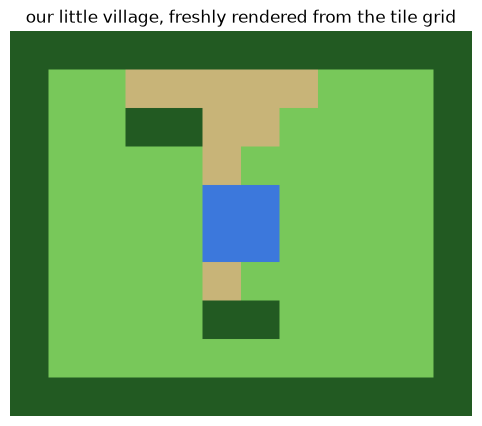

In [2]:
@dataclass
class TileType:
    """A plain data record describing one kind of tile - just data, no behaviour, perfect dataclass use case."""
    color: tuple      # (red, green, blue) used to draw this tile type
    walkable: bool    # can the player/an NPC stand on this tile?


# one TileType per character we use in our map strings below
TILE_TYPES = {
    "T": TileType(color=(34, 90, 34), walkable=False),    # tree/wall - dark green, blocks movement
    ".": TileType(color=(120, 200, 90), walkable=True),   # grass - light green, walkable
    ",": TileType(color=(200, 180, 120), walkable=True),  # stone path/floor - tan, walkable
    "~": TileType(color=(60, 120, 220), walkable=False),  # water - blue, blocks movement (no swimming here)
}

TILE_SIZE = 32  # each tile is a 32x32 pixel square on screen

# our little village map - a list of strings, one string per row, one character per tile
# (border of trees all around, a stone path winding through, and a small pond in the middle)
WORLD_MAP = [
    "TTTTTTTTTTTT",
    "T..,,,,,...T",
    "T..TT,,....T",
    "T....,.....T",
    "T....~~....T",
    "T....~~....T",
    "T....,.....T",
    "T....TT....T",
    "T..........T",
    "TTTTTTTTTTTT",
]

MAP_ROWS = len(WORLD_MAP)          # 10 rows
MAP_COLS = len(WORLD_MAP[0])       # 12 columns (every row must have the same length!)
print(f"map is {MAP_COLS} tiles wide, {MAP_ROWS} tiles tall -> {MAP_COLS * TILE_SIZE}x{MAP_ROWS * TILE_SIZE} pixels")

# our "screen" is just a pygame Surface sized exactly to fit the whole map, tile-perfectly
screen = pygame.display.set_mode((MAP_COLS * TILE_SIZE, MAP_ROWS * TILE_SIZE))


def is_walkable_tile(world_map, grid_x, grid_y):
    """Can something stand on tile (grid_x, grid_y)? checks map bounds AND the tile's walkable flag."""
    if grid_y < 0 or grid_y >= len(world_map):  # off the map vertically -> definitely not walkable
        return False
    row = world_map[grid_y]
    if grid_x < 0 or grid_x >= len(row):  # off the map horizontally -> definitely not walkable
        return False
    tile_char = row[grid_x]
    return TILE_TYPES[tile_char].walkable  # look up the actual walkable flag for this tile type


def render_map(surface, world_map, tile_size):
    """The classic tile-rendering technique: loop over rows and columns, draw one rect per tile."""
    for row_index, row in enumerate(world_map):        # row_index is the tile's grid_y
        for col_index, tile_char in enumerate(row):    # col_index is the tile's grid_x
            color = TILE_TYPES[tile_char].color
            # convert grid coordinates to pixel coordinates by multiplying by the tile size - the key trick!
            pixel_rect = (col_index * tile_size, row_index * tile_size, tile_size, tile_size)
            pygame.draw.rect(surface, color, pixel_rect)


render_map(screen, WORLD_MAP, TILE_SIZE)
show_surface(screen, title="our little village, freshly rendered from the tile grid", figsize=(6, 5))

## the Player class - moving tile by tile
* unlike the free-pixel movement we did in lesson 27 (the bouncing ball), classic RPG movement is TILE BY TILE - the player always sits exactly on one grid cell, and pressing a direction moves them exactly one whole tile over (no smooth in-between pixel positions to worry about)
* so our `Player` stores `grid_x`/`grid_y` (grid coordinates), NOT raw pixel coordinates - we only convert to pixels at the very last moment, when its time to actually draw
* the important part: `move()` checks whether the TARGET tile is walkable BEFORE actually updating the position - this is our collision check. if the target tile is a wall or water, we simply refuse the move and the player stays exactly where they were
* we'll build a small shared `Character` base class first (grid position + drawing), since both the `Player` and our `NPC`s (next section) need exactly that same basic stuff - a nice, natural little bit of inheritance

In [3]:
# direction name -> (delta_x, delta_y) on the grid. "up" means smaller y, since pygame's y grows downwards!
DIRECTION_VECTORS = {
    "up": (0, -1),
    "down": (0, 1),
    "left": (-1, 0),
    "right": (1, 0),
}


class Character:
    """Shared base class for anything that lives on the grid and gets drawn as a colored circle."""

    def __init__(self, grid_x, grid_y, color):
        self.grid_x = grid_x  # column on the grid (NOT a pixel coordinate!)
        self.grid_y = grid_y  # row on the grid
        self.color = color    # (r, g, b) used to draw this character

    def pixel_position(self, tile_size):
        """Convert our grid position into a pixel (x, y) - only needed at drawing time."""
        return (self.grid_x * tile_size, self.grid_y * tile_size)

    def draw(self, surface, tile_size):
        """Our simple sprite-like drawing: a colored circle centered inside this character's tile."""
        pixel_x, pixel_y = self.pixel_position(tile_size)
        center = (pixel_x + tile_size // 2, pixel_y + tile_size // 2)  # middle of the tile
        pygame.draw.circle(surface, self.color, center, tile_size // 2 - 4)  # -4 so it doesnt touch the tile edges


class Player(Character):
    """The player character - adds the actual movement/collision logic on top of Character."""

    def move(self, direction, world_map):
        """Try to move one tile in the given direction. Returns True if it worked, False if blocked."""
        delta_x, delta_y = DIRECTION_VECTORS[direction]
        target_x = self.grid_x + delta_x
        target_y = self.grid_y + delta_y

        # THE collision check: we look at the target tile BEFORE touching self.grid_x/self.grid_y at all
        if is_walkable_tile(world_map, target_x, target_y):
            self.grid_x = target_x  # only now, after the check passed, do we actually update the position
            self.grid_y = target_y
            return True
        return False  # blocked by a wall/water - position is left completely untouched


# quick smoke test: create a player and try moving it around a bit, away from the notebook's later story
test_player = Player(grid_x=1, grid_y=1, color=(240, 220, 60))
print("start:", test_player.grid_x, test_player.grid_y)
print("moved right?", test_player.move("right", WORLD_MAP), "-> now at", (test_player.grid_x, test_player.grid_y))
print("moved into the top-left wall corner?", test_player.move("up", WORLD_MAP), "-> still at", (test_player.grid_x, test_player.grid_y))
# "up" from (2, 1) targets (2, 0), which is the "T" wall tile in the top border row - correctly rejected!

start: 1 1
moved right? True -> now at (2, 1)
moved into the top-left wall corner? False -> still at (2, 1)


## the NPC class - villagers with something to say
* an `NPC` (non-player character) needs the same basic stuff a `Player` needs (a grid position, a color, drawing) - so it makes sense to inherit from our `Character` base class too, this is a genuine "is-a" relationship (an NPC IS a kind of character on the grid)
* but the NPC's DIALOGUE is a different story - a list of strings it can say. that's just data the NPC HAS (composition, recap lesson 08), not something that belongs in the shared `Character` base at all, since a `Player` has no dialogue of its own
* we keep it simple: each NPC cycles through its `dialogue_lines` one at a time (using `%` to wrap back to the start once we run out) - so talking to the same NPC repeatedly shows different lines, then loops

In [4]:
class NPC(Character):
    """A non-player character: stands on one tile forever, and has a few lines of dialogue to say."""

    def __init__(self, grid_x, grid_y, color, name, dialogue_lines):
        super().__init__(grid_x, grid_y, color)  # let the base class set up position/color
        self.name = name                          # this NPC's display name, shown in the dialogue box
        self.dialogue_lines = dialogue_lines       # composition: a plain list of strings this NPC HAS
        self._next_line_index = 0                  # which line comes up next time we talk to this NPC

    def next_dialogue_line(self):
        """Return the next line of dialogue, cycling back to the start once we run out."""
        line = self.dialogue_lines[self._next_line_index % len(self.dialogue_lines)]  # % wraps the index around
        self._next_line_index += 1
        return line


# lets place two villagers on fixed spots on our map (both standing on walkable tiles, obviously)
elder = NPC(
    grid_x=8, grid_y=2, color=(220, 160, 60), name="Elder Maro",
    dialogue_lines=[
        "Welcome to our village, traveler.",
        "Beware the pond spirits living in the water...",
    ],
)
merchant = NPC(
    grid_x=8, grid_y=6, color=(160, 90, 200), name="Merchant Lys",
    dialogue_lines=[
        "Care to see my wares? Come back once you have some coin!",
    ],
)
npcs = [elder, merchant]

# a quick test of the dialogue cycling, completely separate from the "real" playthrough further down
for _ in range(3):
    print(elder.name, "says:", elder.next_dialogue_line())
elder._next_line_index = 0  # reset it back to 0 so our real playthrough below starts from the first line again

Elder Maro says: Welcome to our village, traveler.
Elder Maro says: Beware the pond spirits living in the water...
Elder Maro says: Welcome to our village, traveler.


## the dialogue / interaction system
* the classic RPG interaction rule: you can only talk to an NPC if you're standing right NEXT to them (one tile away, not two, not diagonally through a wall) - we check this with a simple "distance 1 on the grid" test
* when the player triggers an "interact" action and there IS an adjacent NPC, we grab that NPC's next dialogue line and render a text box overlay at the bottom of the screen, using `pygame.font` (recap lesson 27) - this dialogue-box-at-the-bottom look is instantly recognizable to anyone who's played basically any RPG ever

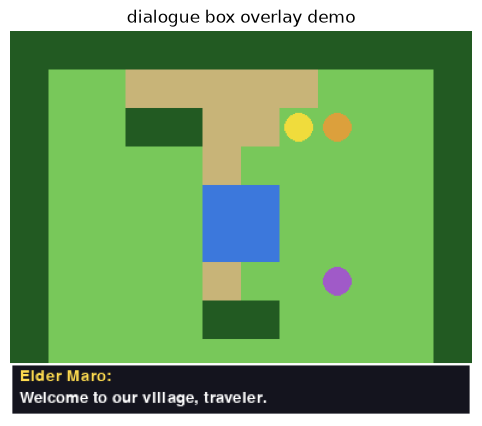

In [5]:
FONT = pygame.font.SysFont(None, 20)  # pygame's built-in default font, small size fits our little screen


def find_adjacent_npc(player, npcs):
    """Return the first NPC standing exactly one tile away from the player (up/down/left/right), or None."""
    for npc in npcs:
        # manhattan distance (sum of the x and y differences) equal to 1 means "exactly one step away, not diagonal"
        distance = abs(player.grid_x - npc.grid_x) + abs(player.grid_y - npc.grid_y)
        if distance == 1:
            return npc
    return None  # nobody close enough to talk to


def draw_dialogue_box(surface, speaker_name, line):
    """Draw a classic RPG-style dialogue box overlay across the bottom of the screen."""
    box_height = 44
    box_rect = pygame.Rect(0, surface.get_height() - box_height, surface.get_width(), box_height)
    pygame.draw.rect(surface, (20, 20, 30), box_rect)          # dark, mostly-opaque background so text is readable
    pygame.draw.rect(surface, (255, 255, 255), box_rect, 2)    # a white outline to make the box pop visually

    name_surface = FONT.render(f"{speaker_name}:", True, (255, 220, 80))  # the speaker's name, in a highlight color
    surface.blit(name_surface, (8, box_rect.y + 4))

    line_surface = FONT.render(line, True, (255, 255, 255))  # the actual dialogue text, in plain white
    surface.blit(line_surface, (8, box_rect.y + 22))


# a tiny standalone demo before we get into the full scripted playthrough
render_map(screen, WORLD_MAP, TILE_SIZE)
for npc in npcs:
    npc.draw(screen, TILE_SIZE)
demo_player = Player(grid_x=7, grid_y=2, color=(240, 220, 60))  # standing right next to the elder
demo_player.draw(screen, TILE_SIZE)
found_npc = find_adjacent_npc(demo_player, npcs)
draw_dialogue_box(screen, found_npc.name, found_npc.next_dialogue_line())
show_surface(screen, title="dialogue box overlay demo", figsize=(6, 5))

## putting it all together: a scripted mini playthrough
* there's obviously no real keyboard attached to this notebook, so instead of a live game loop waiting for real input, we drive the player through the world with a hardcoded, SCRIPTED list of actions - one action per simulated "frame"/step
* our script does a real little tour: walk over to the elder and talk to them, walk down towards the merchant (skirting around the pond) and talk to them too, then deliberately try to walk into a wall tile to prove the collision check actually works, and finally settle on a different tile than we started on
* we grab a snapshot at every meaningful moment (the start, every successful "interact", every BLOCKED move, and the very end) so we can look at the whole mini playthrough afterwards, flipbook-style, just like lesson 27's captured frames

In [6]:
# our fresh player for the real playthrough, starting in the top-left grassy corner of the village
player = Player(grid_x=1, grid_y=1, color=(240, 220, 60))

# the scripted sequence of actions - this stands in for "real" keyboard input, one action per simulated step
ACTIONS = [
    "right", "right", "right", "right", "right", "right",  # walk east along the top row, towards the elder's column
    "down",                                                  # step down - now standing right next to the elder
    "interact",                                              # talk to the elder
    "down", "down", "down", "down",                          # head south, straight down the path, skirting the pond
    "interact",                                              # now standing right next to the merchant - talk to them
    "down",                                                  # one more step down
    "left",                                                  # this deliberately walks straight at a wall tile!
    "down",                                                  # keep heading south
    "right",                                                 # step onto our final resting tile
]

snapshots = []          # list of (label, pixel_array) we'll display at the end
active_dialogue = None  # (speaker_name, line) while a dialogue box should be visible, else None


def render_frame(active_dialogue):
    """Draw the whole current game state (map + NPCs + player + optional dialogue box) onto `screen`."""
    render_map(screen, WORLD_MAP, TILE_SIZE)
    for npc in npcs:
        npc.draw(screen, TILE_SIZE)
    player.draw(screen, TILE_SIZE)
    if active_dialogue is not None:
        speaker_name, line = active_dialogue
        draw_dialogue_box(screen, speaker_name, line)


def capture_snapshot(label):
    """Grab a copy of the current screen pixels and remember it under `label`, for the flipbook later."""
    pixel_array = pygame.surfarray.array3d(screen).swapaxes(0, 1).copy()  # .copy() - screen keeps changing later!
    snapshots.append((label, pixel_array))


# frame 0: the very start, before anything happens
render_frame(active_dialogue)
capture_snapshot("start")

for step_index, action in enumerate(ACTIONS):
    if action == "interact":
        nearby_npc = find_adjacent_npc(player, npcs)
        if nearby_npc is not None:
            dialogue_line = nearby_npc.next_dialogue_line()
            active_dialogue = (nearby_npc.name, dialogue_line)
            print(f"step {step_index:2d}: talked to {nearby_npc.name} -> \"{dialogue_line}\"")
        else:
            active_dialogue = None
            print(f"step {step_index:2d}: pressed interact, but nobody is close enough to talk to")
        render_frame(active_dialogue)
        capture_snapshot(f"interact (step {step_index})")
        active_dialogue = None  # our simple demo only shows the box for the one frame right after interacting
    else:
        moved_successfully = player.move(action, WORLD_MAP)
        position_now = (player.grid_x, player.grid_y)
        if moved_successfully:
            print(f"step {step_index:2d}: moved {action:>5s} -> now at {position_now}")
        else:
            print(f"step {step_index:2d}: tried to move {action:>5s} but that tile is blocked! still at {position_now}")
        render_frame(None)
        if not moved_successfully:
            capture_snapshot(f"BLOCKED {action} (step {step_index})")  # always capture a rejected move, its interesting!

# and one final snapshot once the whole scripted sequence has finished
render_frame(None)
capture_snapshot("final")

print()
print(f"captured {len(snapshots)} snapshots across {len(ACTIONS)} scripted steps")
print("player ended the playthrough at grid position:", (player.grid_x, player.grid_y))

step  0: moved right -> now at (2, 1)
step  1: moved right -> now at (3, 1)
step  2: moved right -> now at (4, 1)
step  3: moved right -> now at (5, 1)
step  4: moved right -> now at (6, 1)
step  5: moved right -> now at (7, 1)
step  6: moved  down -> now at (7, 2)
step  7: talked to Elder Maro -> "Beware the pond spirits living in the water..."
step  8: moved  down -> now at (7, 3)
step  9: moved  down -> now at (7, 4)
step 10: moved  down -> now at (7, 5)
step 11: moved  down -> now at (7, 6)
step 12: talked to Merchant Lys -> "Care to see my wares? Come back once you have some coin!"
step 13: moved  down -> now at (7, 7)
step 14: tried to move  left but that tile is blocked! still at (7, 7)
step 15: moved  down -> now at (7, 8)
step 16: moved right -> now at (8, 8)

captured 5 snapshots across 17 scripted steps
player ended the playthrough at grid position: (8, 8)


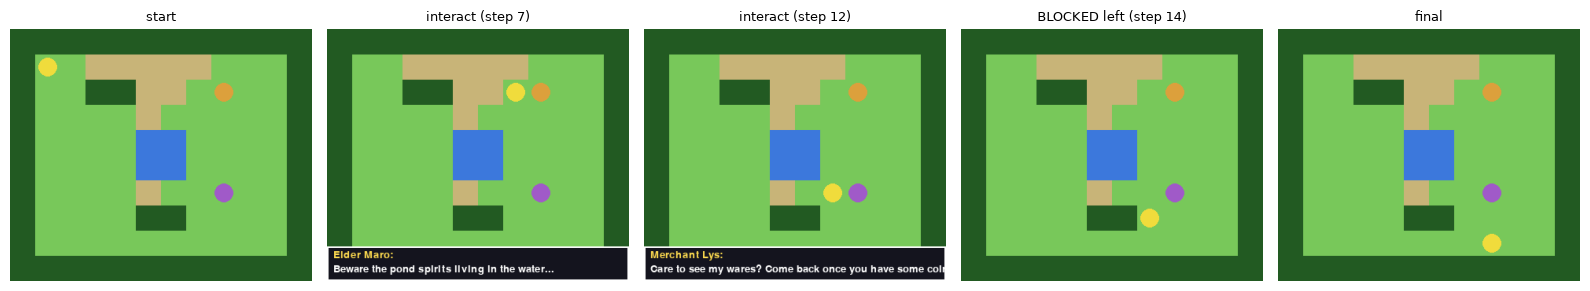

In [7]:
# lets look at the whole mini playthrough side by side, flipbook style (same idea as lesson 27)
fig, axes = plt.subplots(1, len(snapshots), figsize=(3.2 * len(snapshots), 3.2))
for ax, (label, pixels) in zip(axes, snapshots):
    ax.imshow(pixels)
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## quick comparison to other languages/engines
* this "tile grid + player + NPCs + dialogue box" structure is literally the core of the entire SNES/Game Boy era RPG genre - Pokemon, early Final Fantasy, classic Zelda games are all, at their heart, exactly this idea, just with a lot more content, art and polish piled on top
* it's also still the backbone of countless MODERN indie RPGs, most commonly built in **Godot** (GDScript, or C#) or **RPG Maker** - RPG Maker deserves a special mention here: its whole selling point is being a hugely popular NO-CODE (or very-little-code) tool built specifically for exactly this genre, aimed squarely at non-programmers who want to make an RPG without writing a game engine from scratch. its scripting language has historically been Ruby (RPG Maker XP/VX/VX Ace) and is JavaScript-based in the current RPG Maker MZ
* what we're doing here with plain pygame is the polar opposite philosophy: the "understand and build everything yourself" approach - no editor, no built-in tilemap tool, no built-in dialogue system, we wrote all of it ourselves from first principles. more work, but you understand every single piece of it
* dialogue/interaction boxes are SO universal across this genre that they're basically considered one of its defining UI conventions - you'll find some version of "walk up to a character/sign, press a button, a text box slides up from the bottom" in practically every RPG ever shipped, in any language or engine, from 1987's original Final Fantasy in assembly-flavored 6502/Z80 code all the way to a brand new RPG Maker MZ or Godot project today

## Exercises
1. add a THIRD NPC to the village, at a new map position of your choice (make sure its a walkable tile!), with its own unique `dialogue_lines`
2. add a brand new tile type to the game - e.g. a `"D"` door tile - by adding an entry to `TILE_TYPES` (pick a color, decide if its walkable) and placing at least one `D` character somewhere in a copy of `WORLD_MAP`
3. extend the `Player` class with a `facing_direction` attribute (default `"down"`) that updates to whatever direction was just moved in (even if the move was blocked!) - then run a small scripted sequence of moves and print `facing_direction` after each one
4. write a scripted sequence that deliberately tries to walk the player straight into a wall tile, and print the player's position before and after the attempt to CONFIRM it did not change

In [8]:
# TODO: solve exercise 1 here (a third NPC with its own dialogue, at a new position)


# TODO: solve exercise 2 here (a new "D" door tile added to TILE_TYPES and placed on the map)


# TODO: solve exercise 3 here (Player with a facing_direction attribute, updated every move)


# TODO: solve exercise 4 here (deliberately walk into a wall, confirm the position did not change)

### sample solutions
* try the exercises above yourself first, only look here if you are stuck or want to compare your approach

In [9]:
# sample solution 1 - a third NPC with its own dialogue, at a new position
guard = NPC(
    grid_x=3, grid_y=8, color=(90, 160, 220), name="Guard Petra",
    dialogue_lines=["Halt! ...just kidding, welcome through. Watch out for the pond spirits."],
)
npcs_with_guard = npcs + [guard]
print([npc.name for npc in npcs_with_guard])


# sample solution 2 - a new "D" door tile
TILE_TYPES_WITH_DOOR = dict(TILE_TYPES)  # copy, so we dont mess with the original TILE_TYPES used above
TILE_TYPES_WITH_DOOR["D"] = TileType(color=(120, 80, 40), walkable=True)  # a brown door, walkable (you can go through it)

WORLD_MAP_WITH_DOOR = WORLD_MAP.copy()
WORLD_MAP_WITH_DOOR[8] = "T....D.....T"  # swap one grass tile in the bottom row for our new door tile
print(WORLD_MAP_WITH_DOOR[8])
print("is the door tile walkable?", TILE_TYPES_WITH_DOOR["D"].walkable)


# sample solution 3 - Player with a facing_direction attribute
class PlayerWithFacing(Player):
    def __init__(self, grid_x, grid_y, color):
        super().__init__(grid_x, grid_y, color)
        self.facing_direction = "down"  # a sensible default, matches most RPGs' default sprite facing

    def move(self, direction, world_map):
        self.facing_direction = direction  # update facing even if the move below turns out to be blocked!
        return super().move(direction, world_map)  # reuse all of the real move/collision logic from Player


facing_player = PlayerWithFacing(grid_x=1, grid_y=1, color=(240, 220, 60))
# right x6 then down x6 retraces our main playthrough's path, then one final "left" walks straight into a wall
facing_moves = ["right"] * 6 + ["down"] * 6 + ["left"]
for direction in facing_moves:
    moved = facing_player.move(direction, WORLD_MAP)
    status = "moved  " if moved else "BLOCKED"  # padded so the printout lines up nicely
    print(f"{status} {direction:>5s} -> facing_direction is now {facing_player.facing_direction!r}, at ({facing_player.grid_x}, {facing_player.grid_y})")


# sample solution 4 - deliberately walk into a wall and confirm the position did not change
wall_test_player = Player(grid_x=1, grid_y=0 + 1, color=(240, 220, 60))  # (1, 1), same as our main playthrough start
position_before = (wall_test_player.grid_x, wall_test_player.grid_y)
result = wall_test_player.move("up", WORLD_MAP)  # (1, 1) -> (1, 0) is the top wall border, must be rejected
position_after = (wall_test_player.grid_x, wall_test_player.grid_y)

print("position before the attempt:", position_before)
print("move into the wall returned:", result)
print("position after the attempt: ", position_after)
print("position unchanged?", position_before == position_after)

['Elder Maro', 'Merchant Lys', 'Guard Petra']
T....D.....T
is the door tile walkable? True
moved   right -> facing_direction is now 'right', at (2, 1)
moved   right -> facing_direction is now 'right', at (3, 1)
moved   right -> facing_direction is now 'right', at (4, 1)
moved   right -> facing_direction is now 'right', at (5, 1)
moved   right -> facing_direction is now 'right', at (6, 1)
moved   right -> facing_direction is now 'right', at (7, 1)
moved    down -> facing_direction is now 'down', at (7, 2)
moved    down -> facing_direction is now 'down', at (7, 3)
moved    down -> facing_direction is now 'down', at (7, 4)
moved    down -> facing_direction is now 'down', at (7, 5)
moved    down -> facing_direction is now 'down', at (7, 6)
moved    down -> facing_direction is now 'down', at (7, 7)
BLOCKED  left -> facing_direction is now 'left', at (7, 7)
position before the attempt: (1, 1)
move into the wall returned: False
position after the attempt:  (1, 1)
position unchanged? True


* congratulation you finished this lesson

## what we learned
* what an RPG (role playing game) actually is under the hood: a tile-based world + characters + collision + dialogue, and how this lesson (world/player/NPCs) sets up part 2's items and battles (lesson 32)
* representing a tile-based world as a list of strings, and the classic nested-loop "draw one rect per tile at `(col * tile_size, row * tile_size)`" rendering technique
* using a `@dataclass` (`TileType`) to bundle a tile's color and walkability into one clean data record, instead of juggling two parallel dicts
* a `Character` base class shared by `Player` and `NPC` (a genuine "is-a" inheritance relationship), with `NPC`'s dialogue lines being composition ("has-a") on top of that
* tile-by-tile grid movement (`grid_x`/`grid_y`, not raw pixels) and a `move()` method that checks the target tile is walkable BEFORE moving there - our collision system
* a simple dialogue/interaction system: checking adjacency on the grid, cycling through an NPC's dialogue lines, and rendering a classic RPG-style text box overlay with `pygame.font`
* driving a "playable" scripted mini playthrough with a hardcoded action list instead of live keyboard input, and capturing snapshots at the meaningful moments to see the whole thing as a flipbook
* how universal this exact structure (tile grid + NPCs + dialogue box) is across the whole RPG genre, in every engine/language that has ever shipped one, from RPG Maker's no-code approach to hand-rolling it yourself in pygame